In [2]:
import pandas as pd
import numpy as np

In [4]:
file_path = 'elektrik_veri.xlsx'
xls = pd.ExcelFile(file_path)

In [6]:
print("Sayfa isimleri:", xls.sheet_names)


Sayfa isimleri: ['Tahsilat', 'Tahsilat 1', 'Tahakkuk', 'Tahakkuk 1', 'Tahakkuk 2']


In [11]:
df_tahsilat = pd.read_excel(xls, sheet_name='Tahsilat')
df_tahsilat_1 = pd.read_excel(xls, sheet_name='Tahsilat 1')
df_tahakkuk = pd.read_excel(xls, sheet_name='Tahakkuk')      # Hamamözü
df_tahakkuk_1 = pd.read_excel(xls, sheet_name='Tahakkuk 1')  # Gümüşhacıköy
df_tahakkuk_2 = pd.read_excel(xls, sheet_name='Tahakkuk 2')  # Göynücek

In [12]:
print(f"Tahsilat: {df_tahsilat.shape}")
print(f"Tahsilat 1: {df_tahsilat_1.shape}")
print(f"Tahakkuk (Hamamözü): {df_tahakkuk.shape}")
print(f"Tahakkuk 1 (Gümüşhacıköy): {df_tahakkuk_1.shape}")
print(f"Tahakkuk 2 (Göynücek): {df_tahakkuk_2.shape}")

Tahsilat: (636993, 9)
Tahsilat 1: (917632, 22)
Tahakkuk (Hamamözü): (124818, 10)
Tahakkuk 1 (Gümüşhacıköy): (765657, 10)
Tahakkuk 2 (Göynücek): (295223, 10)


In [13]:
# notebook - 1 için

In [15]:
dfs = {
    "Tahsilat": df_tahsilat,
    "Tahsilat 1": df_tahsilat_1,
    "Tahakkuk (Hamamözü)": df_tahakkuk,
    "Tahakkuk 1 (Gümüşhacıköy)": df_tahakkuk_1,
    "Tahakkuk 2 (Göynücek)": df_tahakkuk_2
}

In [16]:
for name, df in dfs.items():
    print(f"\n--- {name} ---")
    print("\nINFO:")
    print(df.info())
    print("\nDESCRIBE:")
    print(df.describe(include='all'))
    print("\nHEAD:")
    print(df.head())


--- Tahsilat ---

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636993 entries, 0 to 636992
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Şube                   636993 non-null  object        
 1   Kasa                   636993 non-null  object        
 2   İlçe                   636993 non-null  object        
 3   Söz.hsp.(bağımsız)     636993 non-null  int64         
 4   Tahsilat Tarihi        636993 non-null  datetime64[ns]
 5   Nakit Tahsilat         523 non-null     float64       
 6   Mahsuben Tahsilat      7542 non-null    float64       
 7   Kredi Kartı Tahsilatı  0 non-null       float64       
 8   Banka Tahsilatı        628933 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 43.7+ MB
None

DESCRIBE:
             Şube    Kasa    İlçe  Söz.hsp.(bağımsız)  \
count      636993  636993  636993        6.369930e

In [17]:
hamamozu_unique = df_tahakkuk['sozlesme_hesap_no'].nunique()
gumushacikoy_unique = df_tahakkuk_1['sozlesme_hesap_no'].nunique()
goynucek_unique = df_tahakkuk_2['sozlesme_hesap_no'].nunique()

print("Hamamözü benzersiz müşteri sayısı:", hamamozu_unique)
print("Gümüşhacıköy benzersiz müşteri sayısı:", gumushacikoy_unique)
print("Göynücek benzersiz müşteri sayısı:", goynucek_unique)

Hamamözü benzersiz müşteri sayısı: 2981
Gümüşhacıköy benzersiz müşteri sayısı: 18190
Göynücek benzersiz müşteri sayısı: 7128


In [18]:

df_tahakkuk_all = pd.concat(
    [df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2],
    axis=0,
    ignore_index=True
)


print("Birleştirilmiş toplam kayıt sayısı:", df_tahakkuk_all.shape[0])


expected_total = (
    df_tahakkuk.shape[0] +
    df_tahakkuk_1.shape[0] +
    df_tahakkuk_2.shape[0]
)

print("Beklenen toplam:", expected_total)


print("Eşleşiyor mu?:", df_tahakkuk_all.shape[0] == expected_total)

Birleştirilmiş toplam kayıt sayısı: 1185698
Beklenen toplam: 1185698
Eşleşiyor mu?: True


In [19]:
missing_count = df_tahakkuk_all['kwh'].isnull().sum()

print("Eksik değer sayısı:", missing_count)

Eksik değer sayısı: 0


In [20]:
negative_count = (df_tahakkuk_all['kwh'] < 0).sum()

print("Negatif değer sayısı:", negative_count)

# Negatif kayıtları görmek
df_tahakkuk_all[df_tahakkuk_all['kwh'] < 0].head()

Negatif değer sayısı: 151


,il,ilce,sozlesme_hesap_no,mali_yil_donem,fatura_tarihi,kayit_tarihi,vade_tarihi,hesap_sinifi,Hesap Sınıfı,kwh
23573,AMASYA,HAMAMÖZÜ,7904741733,2025-03-01,2025-04-14,2025-06-10,2025-04-22,M001,Mesken,-1242.99
23576,AMASYA,HAMAMÖZÜ,7904741733,2025-04-01,2025-04-14,2025-06-10,2025-04-22,M001,Mesken,-733.04
28413,AMASYA,HAMAMÖZÜ,469034964,2023-10-01,2023-10-11,2023-11-28,2023-10-23,M001,Mesken,-1.04
70626,AMASYA,HAMAMÖZÜ,7722066065,2023-10-01,2023-10-23,2023-11-28,2023-11-02,M001,Mesken,-1.34
180501,AMASYA,GÜMÜŞHACIKÖY,2945215788,2024-02-01,2024-04-15,2024-06-15,2024-03-25,M001,Mesken,-374.09


In [21]:
Q1 = df_tahakkuk_all['kwh'].quantile(0.25)
Q3 = df_tahakkuk_all['kwh'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = df_tahakkuk_all[
    (df_tahakkuk_all['kwh'] < lower_bound) |
    (df_tahakkuk_all['kwh'] > upper_bound)
].shape[0]

print("Alt sınır:", lower_bound)
print("Üst sınır:", upper_bound)
print("Aşırı uç değer sayısı:", outlier_count)

Alt sınır: -74.97499999999998
Üst sınır: 172.98499999999999
Aşırı uç değer sayısı: 48554


In [22]:
tuketim_istatistik = (
    df_tahakkuk_all
    .groupby("hesap_sinifi")["kwh"]
    .agg(
        Ortalama="mean",
        Medyan="median",
        Std_Sapma="std"
    )
    .reset_index()
)

print(tuketim_istatistik)

   hesap_sinifi      Ortalama     Medyan     Std_Sapma
0             1  16594.174857  16186.910  11656.705924
1             3    579.850961    150.830   1693.273715
2             4    600.581235     78.270   3350.978976
3             6  16155.254444    322.320  35926.424902
4             7   1195.051389    770.625   1229.579483
5          A001     32.435252     13.940    112.225490
6          A002  30203.431220  36810.900  16963.572539
7          A003     31.951003     18.390     38.472449
8          M001     55.590010     47.360     73.902931
9          M002     81.283512     56.140    111.164648
10         M003     93.101238     29.585    141.698975
11         M004     10.713755      5.625     16.453958
12         M006     34.289765      9.140     60.020356
13         M007     73.615948     73.865     39.066907
14         M008      9.097143      5.000      9.346247
15         M009    167.135000     22.115    526.354274
16         S001   7293.799626   1531.680  13716.343807
17        

In [ ]:
# notebook - 2 için veri görselleştirme

In [23]:
import matplotlib.pyplot as plt

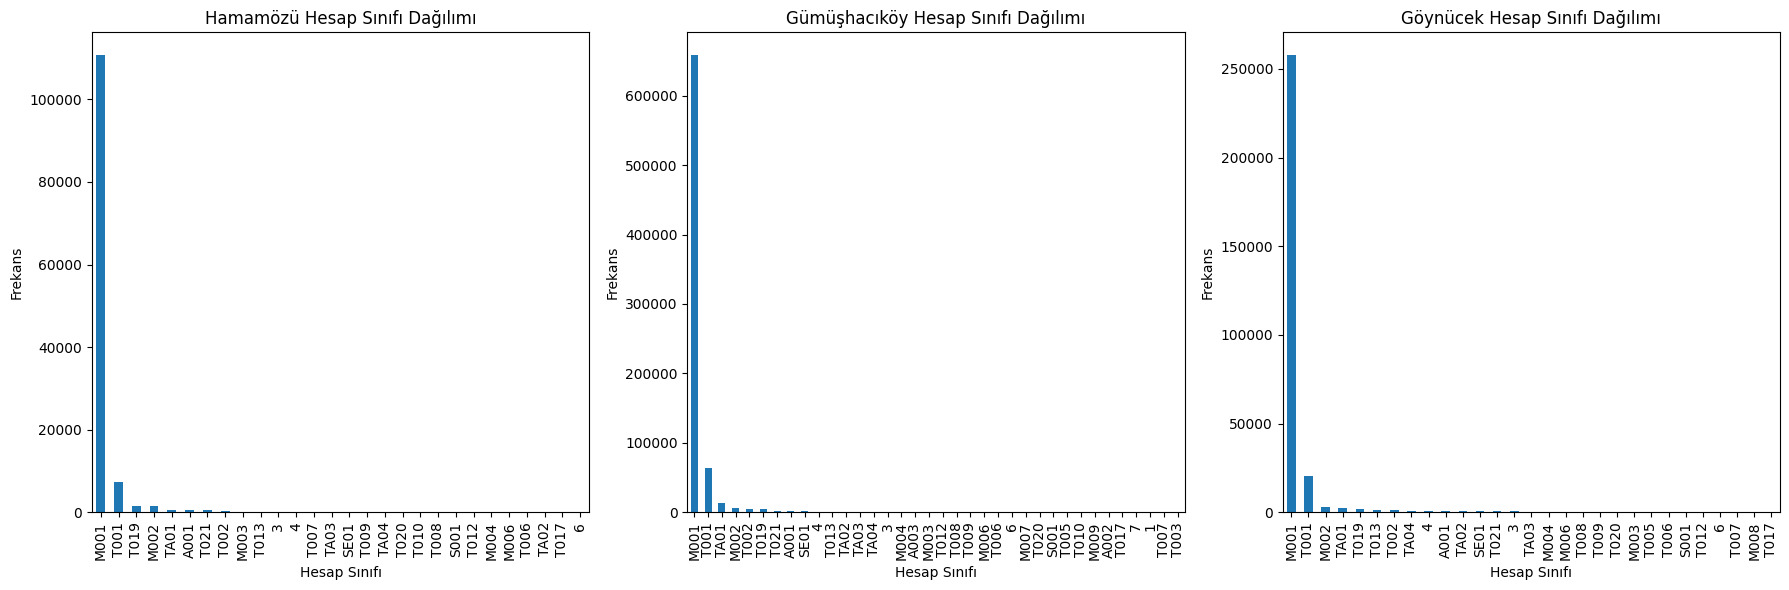

In [24]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Hamamözü
df_tahakkuk["hesap_sinifi"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Hamamözü Hesap Sınıfı Dağılımı")
axes[0].set_xlabel("Hesap Sınıfı")
axes[0].set_ylabel("Frekans")

# Gümüşhacıköy
df_tahakkuk_1["hesap_sinifi"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Gümüşhacıköy Hesap Sınıfı Dağılımı")
axes[1].set_xlabel("Hesap Sınıfı")
axes[1].set_ylabel("Frekans")

# Göynücek
df_tahakkuk_2["hesap_sinifi"].value_counts().plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("Göynücek Hesap Sınıfı Dağılımı")
axes[2].set_xlabel("Hesap Sınıfı")
axes[2].set_ylabel("Frekans")

plt.tight_layout()
plt.show()

In [26]:

df_tahakkuk["Ilce"] = "Hamamözü"
df_tahakkuk_1["Ilce"] = "Gümüşhacıköy"
df_tahakkuk_2["Ilce"] = "Göynücek"


df_all = pd.concat(
    [df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2],
    ignore_index=True
)

In [28]:
df_all["fatura_tarihi"] = pd.to_datetime(df_all["fatura_tarihi"])

In [30]:

df_all["YilAy"] = df_all["fatura_tarihi"].dt.to_period("M")

aylik_ortalama = (
    df_all
    .groupby(["Ilce", "YilAy"])
    ["kwh"]
    .mean()
    .reset_index()
)

aylik_ortalama["YilAy"] = aylik_ortalama["YilAy"].dt.to_timestamp()

print(aylik_ortalama.head())


       Ilce      YilAy        kwh
0  Göynücek 2023-01-01  89.785971
1  Göynücek 2023-02-01  76.318026
2  Göynücek 2023-03-01  73.337335
3  Göynücek 2023-04-01  67.046092
4  Göynücek 2023-05-01  71.102825


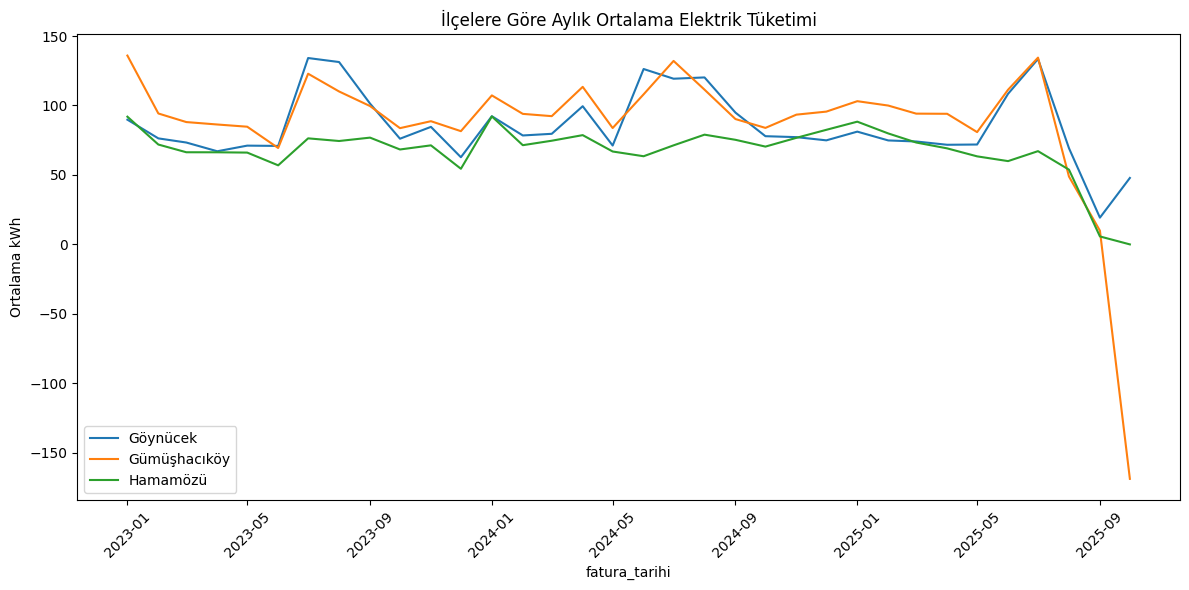

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for ilce in aylik_ortalama["Ilce"].unique():
    data = aylik_ortalama[aylik_ortalama["Ilce"] == ilce]
    plt.plot(data["YilAy"], data["kwh"], label=ilce)

plt.title("İlçelere Göre Aylık Ortalama Elektrik Tüketimi")
plt.xlabel("fatura_tarihi")
plt.ylabel("Ortalama kWh")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

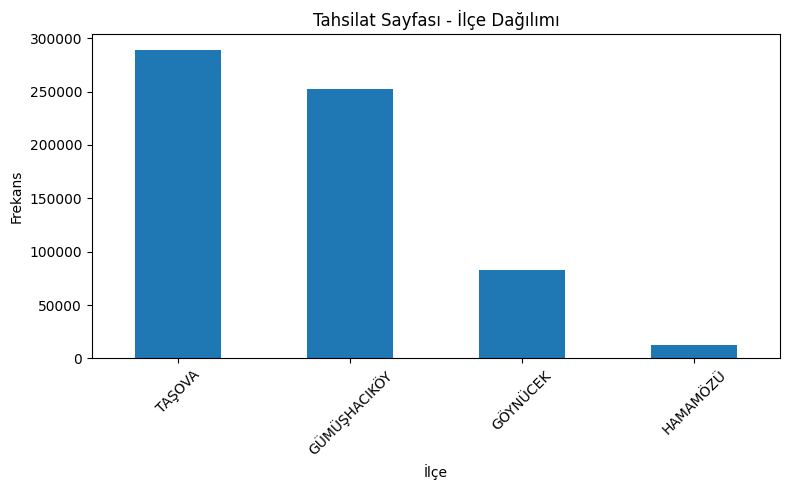

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df_tahsilat["İlçe"].value_counts().plot(kind="bar")

plt.title("Tahsilat Sayfası - İlçe Dağılımı")
plt.xlabel("İlçe")
plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

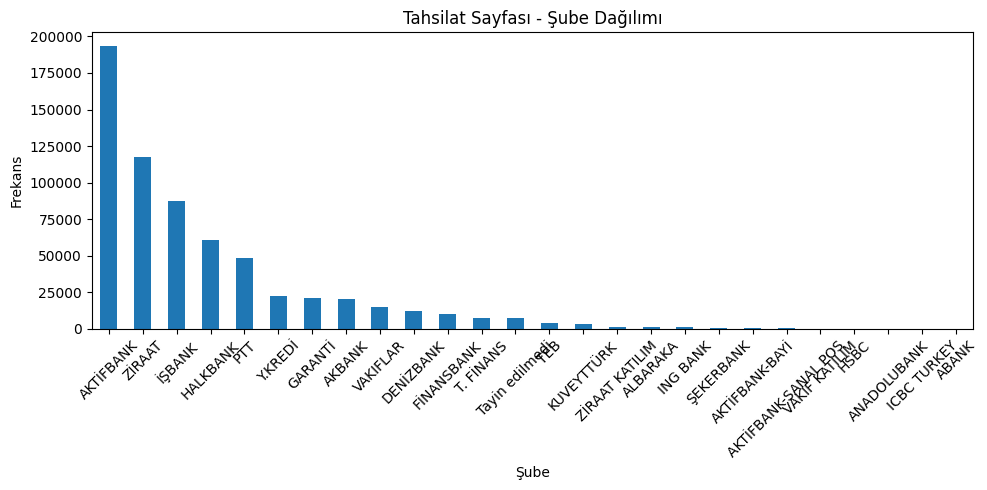

In [35]:
plt.figure(figsize=(10,5))

df_tahsilat["Şube"].value_counts().plot(kind="bar")

plt.title("Tahsilat Sayfası - Şube Dağılımı")
plt.xlabel("Şube")
plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
payment_column = None
for col in df_tahsilat_1.columns:
    if 'ödeme' in col.lower():
        payment_column = col
        break

if payment_column:
    odeme_sayim = df_tahsilat_1[payment_column].value_counts()
    odeme_oran = df_tahsilat_1[payment_column].value_counts(normalize=True) * 100

    print("Ödeme Sayıları:")
    print(odeme_sayim)

    print("\nÖdeme Oranları (%):")
    print(odeme_oran)
else:
    print("No column related to 'Ödeme' found in df_tahsilat_1. Available columns:")
    print(df_tahsilat_1.columns.tolist())

Ödeme Sayıları:
Son Ödeme Tarihinden Önceki Tahsilat
0.01       6381
0.02       6329
0.03       6116
0.04       6103
0.06       5781
           ... 
598.34        1
891.07        1
1691.72       1
959.68        1
1905.08       1
Name: count, Length: 71050, dtype: int64

Ödeme Oranları (%):
Son Ödeme Tarihinden Önceki Tahsilat
0.01       1.022747
0.02       1.014412
0.03       0.980273
0.04       0.978189
0.06       0.926579
             ...   
598.34     0.000160
891.07     0.000160
1691.72    0.000160
959.68     0.000160
1905.08    0.000160
Name: proportion, Length: 71050, dtype: float64


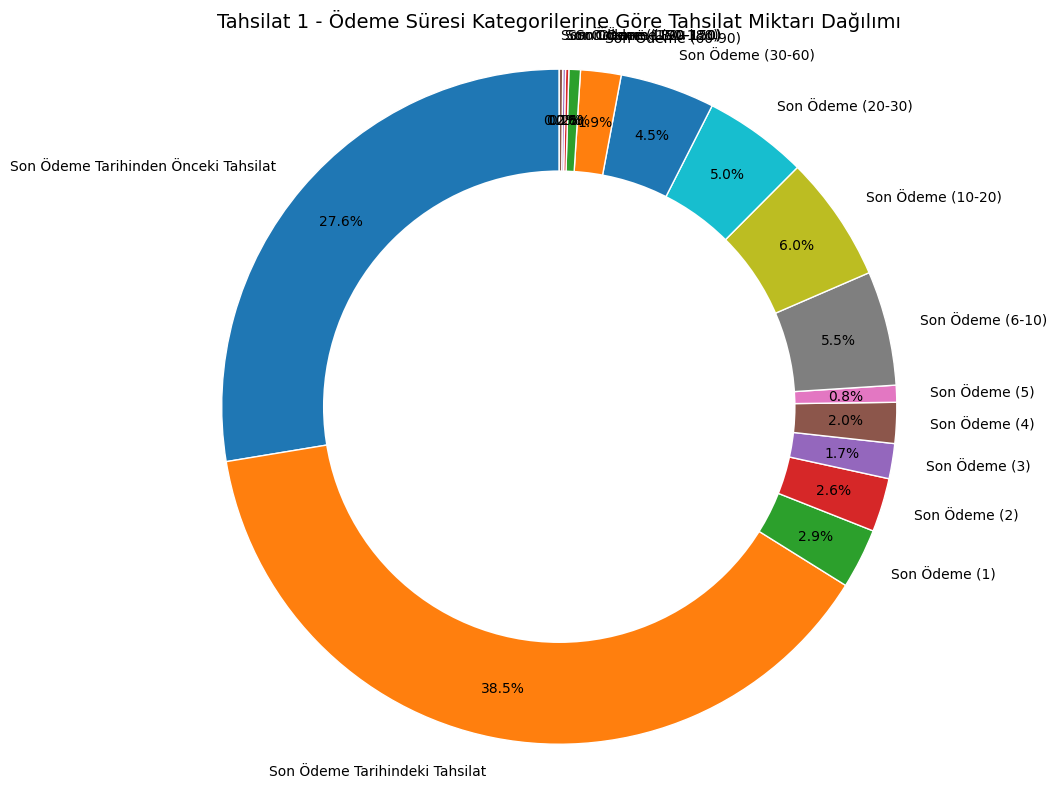

In [51]:
import matplotlib.pyplot as plt



plt.figure(figsize=(10, 8))
plt.pie(
    payment_duration_sums.values,
    labels=payment_duration_sums.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white'}
)


centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Tahsilat 1 - Ödeme Süresi Kategorilerine Göre Tahsilat Miktarı Dağılımı', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

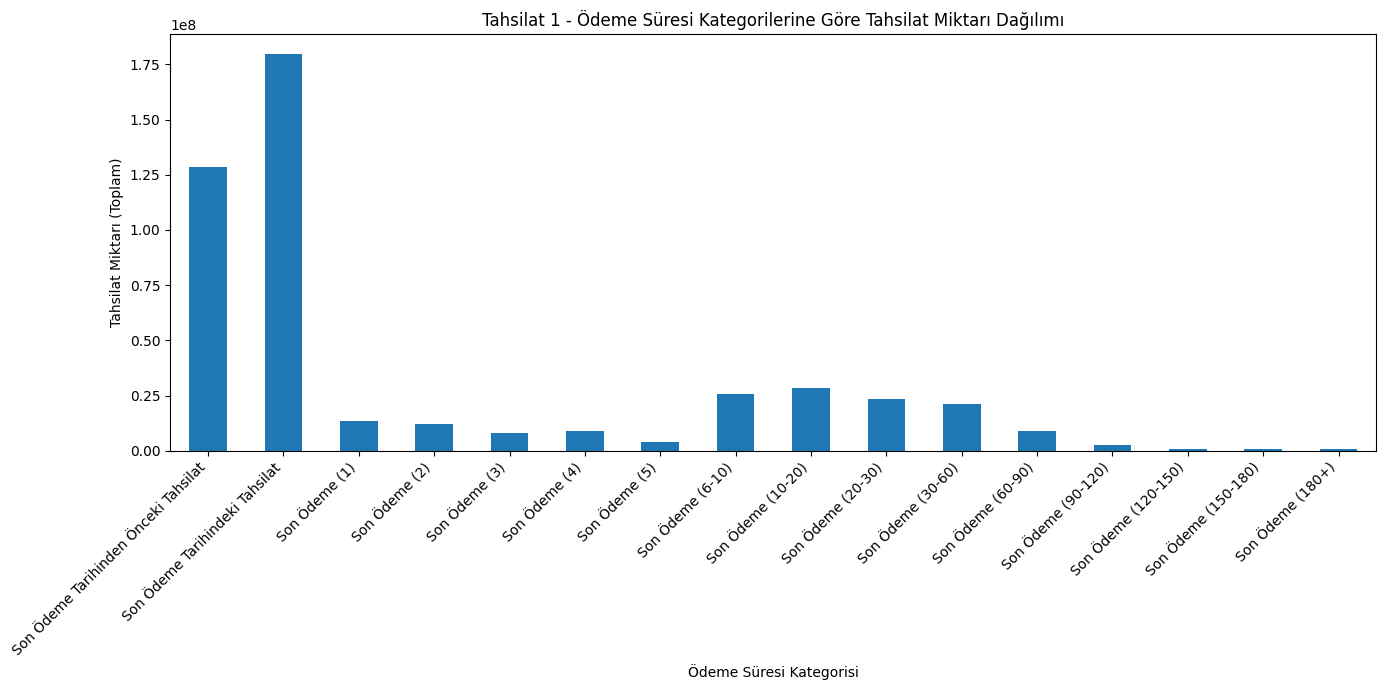

In [47]:
import matplotlib.pyplot as plt

# Identify payment duration columns
payment_duration_cols = [
    'Son Ödeme Tarihinden Önceki Tahsilat',
    'Son Ödeme Tarihindeki Tahsilat',
    'Son Ödeme (1)', 'Son Ödeme (2)', 'Son Ödeme (3)', 'Son Ödeme (4)', 'Son Ödeme (5)',
    'Son Ödeme (6-10)', 'Son Ödeme (10-20)', 'Son Ödeme (20-30)', 'Son Ödeme (30-60)',
    'Son Ödeme (60-90)', 'Son Ödeme (90-120)', 'Son Ödeme (120-150)', 'Son Ödeme (150-180)',
    'Son Ödeme (180+)'
]

# Sum the values for each payment duration category
payment_duration_sums = df_tahsilat_1[payment_duration_cols].sum().fillna(0)

# Filter out categories with zero sum if desired for clearer plot
payment_duration_sums = payment_duration_sums[payment_duration_sums > 0]

# Plotting the distribution
plt.figure(figsize=(14, 7))
payment_duration_sums.plot(kind='bar')

plt.title('Tahsilat 1 - Ödeme Süresi Kategorilerine Göre Tahsilat Miktarı Dağılımı')
plt.xlabel('Ödeme Süresi Kategorisi')
plt.ylabel('Tahsilat Miktarı (Toplam)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Toplam uç değer sayısı: 48554


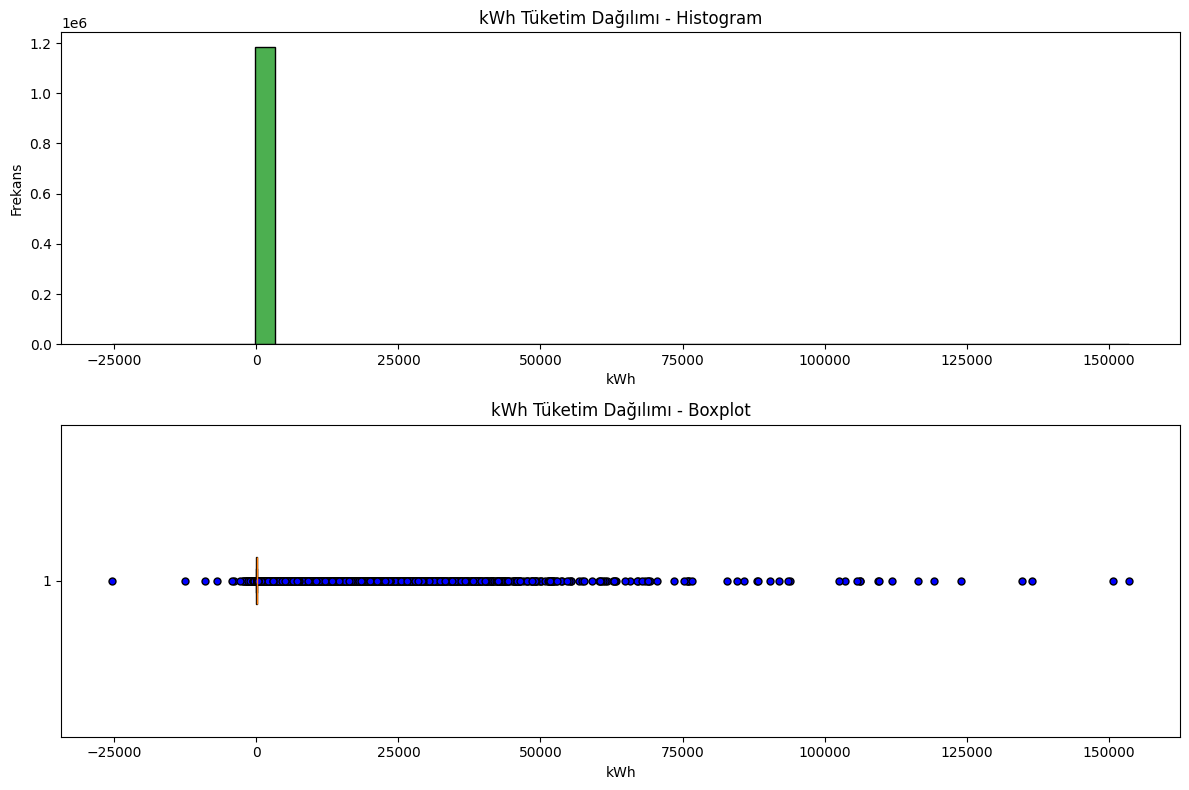

In [49]:
# Outlier
Q1 = df_tahakkuk_all['kwh'].quantile(0.25)
Q3 = df_tahakkuk_all['kwh'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_tahakkuk_all[(df_tahakkuk_all['kwh'] < lower) |
                            (df_tahakkuk_all['kwh'] > upper)]

fig, axes = plt.subplots(2, 1, figsize=(12,8))


axes[0].hist(df_tahakkuk_all['kwh'], bins=50, color='#4CAF50', edgecolor='black')
axes[0].set_title('kWh Tüketim Dağılımı - Histogram')
axes[0].set_xlabel('kWh')
axes[0].set_ylabel('Frekans')


axes[1].boxplot(df_tahakkuk_all['kwh'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#F44336', color='black'),
                flierprops=dict(marker='o', markerfacecolor='blue', markersize=5, linestyle='none'))
axes[1].set_title('kWh Tüketim Dağılımı - Boxplot')
axes[1].set_xlabel('kWh')

print(f"Toplam uç değer sayısı: {outliers.shape[0]}")

plt.tight_layout()
plt.show()

In [ ]:
# notebook - 3 için -- veri hikayesi anlatımı

In [53]:
df_tahakkuk["Ilce"] = "Hamamözü"
df_tahakkuk_1["Ilce"] = "Gümüşhacıköy"
df_tahakkuk_2["Ilce"] = "Göynücek"

df_all = pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2], ignore_index=True)


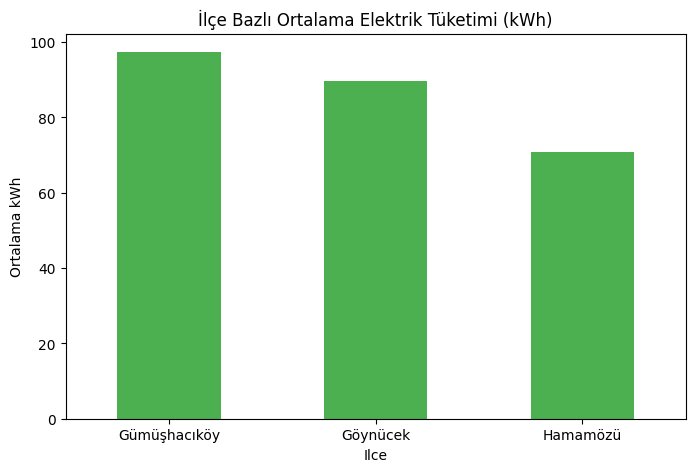

In [54]:
ortalama_kwh = df_all.groupby("Ilce")["kwh"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
ortalama_kwh.plot(kind="bar", color="#4CAF50")
plt.title("İlçe Bazlı Ortalama Elektrik Tüketimi (kWh)")
plt.ylabel("Ortalama kWh")
plt.xticks(rotation=0)
plt.show()

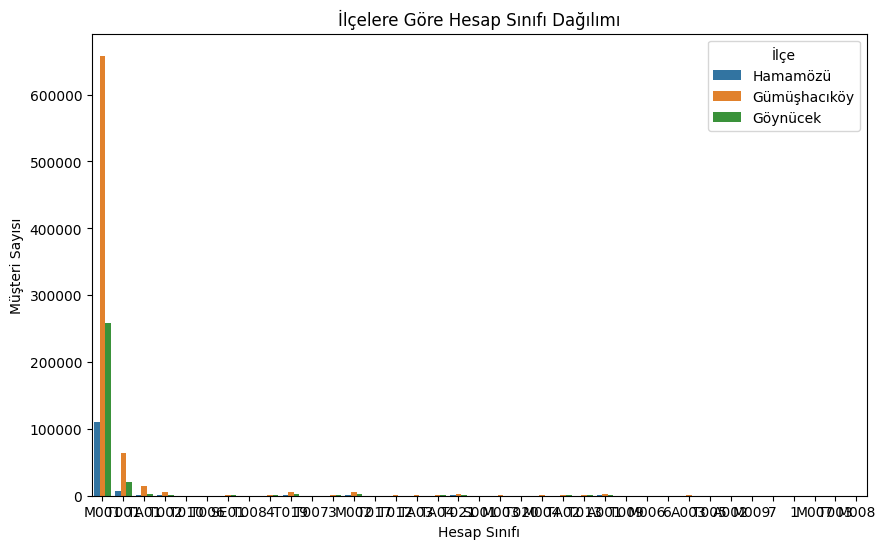

In [55]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=df_all, x="hesap_sinifi", hue="Ilce")
plt.title("İlçelere Göre Hesap Sınıfı Dağılımı")
plt.xlabel("Hesap Sınıfı")
plt.ylabel("Müşteri Sayısı")
plt.legend(title="İlçe")
plt.show()

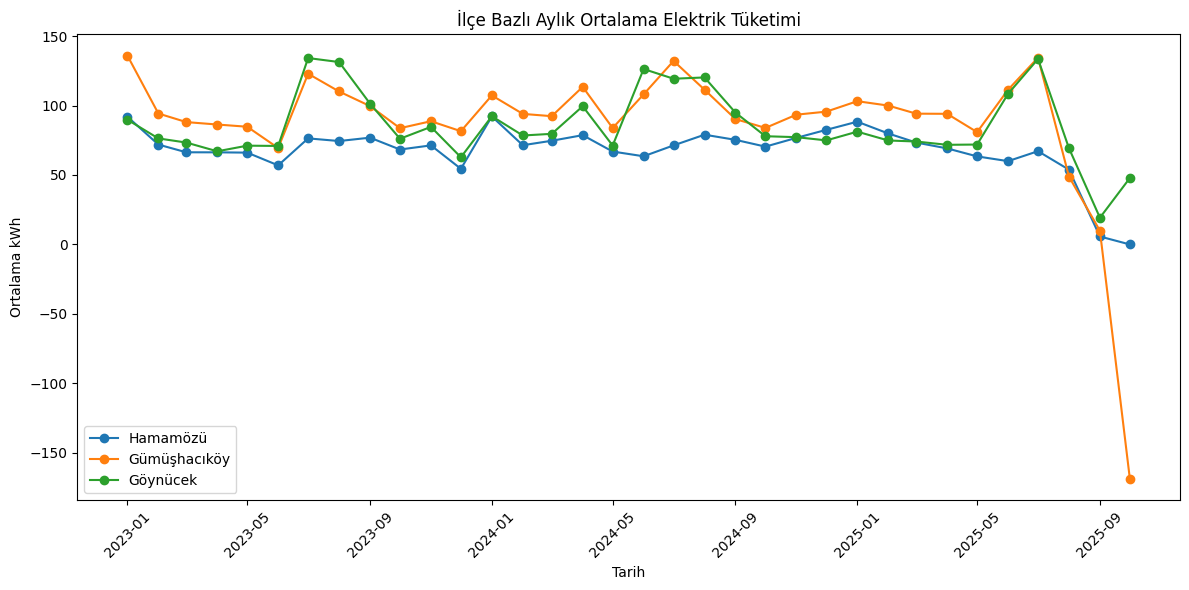

In [58]:
df_all["fatura_tarihi"] = pd.to_datetime(df_all["fatura_tarihi"])
df_all["YilAy"] = df_all["fatura_tarihi"].dt.to_period("M").dt.to_timestamp()

aylik_ortalama = df_all.groupby(["Ilce", "YilAy"])["kwh"].mean().reset_index()

plt.figure(figsize=(12,6))
for ilce in df_all["Ilce"].unique():
    data = aylik_ortalama[aylik_ortalama["Ilce"] == ilce]
    plt.plot(data["YilAy"], data["kwh"], marker='o', label=ilce)

plt.title("İlçe Bazlı Aylık Ortalama Elektrik Tüketimi")
plt.xlabel("Tarih")
plt.ylabel("Ortalama kWh")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
if "Odeme_Durumu" in df_tahsilat_1.columns:
    tahsilat_ilce = df_tahsilat_1.groupby("Ilce")["Odeme_Durumu"].value_counts(normalize=True).unstack()
    tahsilat_ilce.plot(kind="bar", figsize=(10,5), stacked=True, colormap='Set2')
    plt.title("İlçe Bazlı Zamanında vs Geç Ödeme Oranı")
    plt.ylabel("Oran")
    plt.xticks(rotation=0)
    plt.show()

/tmp/ipykernel_527/3398936668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="Ilce", y="kwh", palette="Set3")


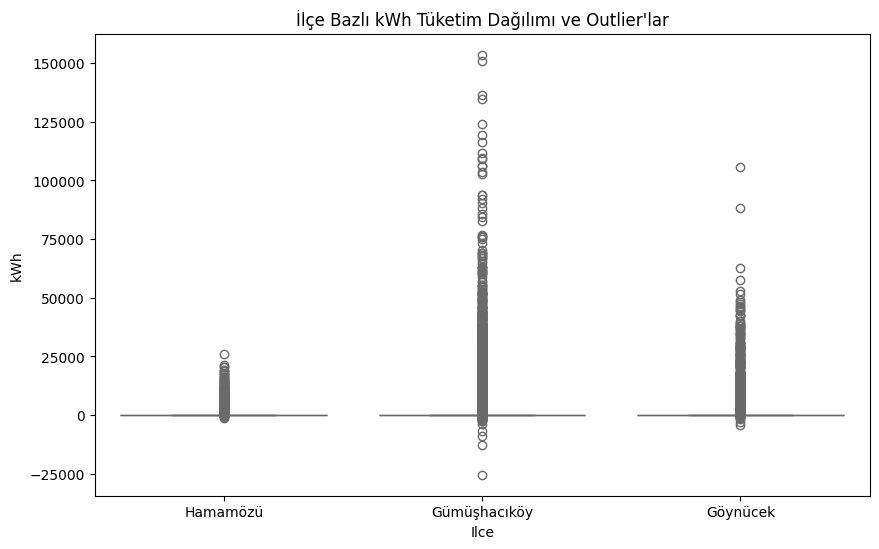

In [61]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_all, x="Ilce", y="kwh", palette="Set3")
plt.title("İlçe Bazlı kWh Tüketim Dağılımı ve Outlier'lar")
plt.ylabel("kWh")
plt.show()

                  kwh  Odeme_Binary  Müşteri Sayısı
Segment                                            
0           53.616980      0.000000           94704
1           80.015683      1.000000           29986
2        10697.933203      0.328125             128


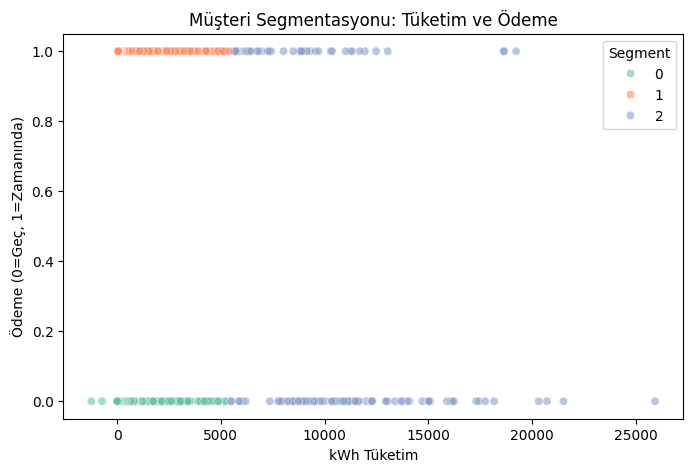


Segment 0 → Yüksek tüketim, zamanında ödeme → Sadakat programları, premium teklifler
Segment 1 → Orta tüketim, geç ödeme → Ödeme hatırlatmaları, teşvikler
Segment 2 → Düşük tüketim, zamanında veya geç ödeme → Standart teklifler, uyarılar



In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


payment_status_agg = df_tahsilat_1.groupby('Söz.hsp.(bağımsız)')\
                                 ['Son Ödeme (1)'].apply(lambda x: (x > 0).any()).astype(int).reset_index()
payment_status_agg = payment_status_agg.rename(columns={'Söz.hsp.(bağımsız)': 'sozlesme_hesap_no', 'Son Ödeme (1)': 'Odeme_Binary'})


X = df_tahakkuk[['kwh', 'sozlesme_hesap_no']].copy()


X = pd.merge(X, payment_status_agg, on='sozlesme_hesap_no', how='left')


X['Odeme_Binary'] = X['Odeme_Binary'].fillna(0)


X_features = X[['kwh', 'Odeme_Binary']].dropna()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X_features['Segment'] = kmeans.fit_predict(X_scaled)


print(X_features.groupby('Segment').agg({'kwh':'mean','Odeme_Binary':'mean','Segment':'count'}).rename(columns={'Segment':'Müşteri Sayısı'}))


plt.figure(figsize=(8,5))
sns.scatterplot(data=X_features, x='kwh', y='Odeme_Binary', hue='Segment', palette='Set2', alpha=0.6)
plt.title("Müşteri Segmentasyonu: Tüketim ve Ödeme")
plt.xlabel("kWh Tüketim")
plt.ylabel("Ödeme (0=Geç, 1=Zamanında)")
plt.show()


print("""
Segment 0 → Yüksek tüketim, zamanında ödeme → Sadakat programları, premium teklifler
Segment 1 → Orta tüketim, geç ödeme → Ödeme hatırlatmaları, teşvikler
Segment 2 → Düşük tüketim, zamanında veya geç ödeme → Standart teklifler, uyarılar
""")

In [79]:

df_tahsilat_1['Odeme_Binary'] = df_tahsilat_1['Son Ödeme (1)'].apply(lambda x: 1 if x>0 else 0)


gec_sutunlar = ['Son Ödeme (2)','Son Ödeme (3)','Son Ödeme (4)',
                'Son Ödeme (5)','Son Ödeme (6-10)','Son Ödeme (10-20)',
                'Son Ödeme (20-30)','Son Ödeme (30-60)','Son Ödeme (60-90)',
                'Son Ödeme (90-120)','Son Ödeme (120-150)','Son Ödeme (150-180)',
                'Son Ödeme (180+)']

df_tahsilat_1['Gec_Odeme_Sayisi'] = df_tahsilat_1[gec_sutunlar].sum(axis=1)


df_tahsilat_1['Risk_Skor'] = df_tahsilat_1['Gec_Odeme_Sayisi'] / (df_tahsilat_1['Gec_Odeme_Sayisi'] + df_tahsilat_1['Son Ödeme (1)'])

In [80]:
def risk_grubu(x):
    if x==0:
        return 'Düşük Risk'
    elif x<0.3:
        return 'Orta Risk'
    elif x<0.6:
        return 'Yüksek Risk'
    else:
        return 'Çok Yüksek Risk'

df_tahsilat_1['Risk_Grubu'] = df_tahsilat_1['Risk_Skor'].apply(risk_grubu)


print(df_tahsilat_1['Risk_Grubu'].value_counts())

Risk_Grubu
Çok Yüksek Risk    896770
Düşük Risk          20757
Orta Risk              65
Yüksek Risk            40
Name: count, dtype: int64


/tmp/ipykernel_527/2066933718.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tahsilat_1, x='Risk_Grubu', palette='Set1', order=['Düşük Risk','Orta Risk','Yüksek Risk','Çok Yüksek Risk'])


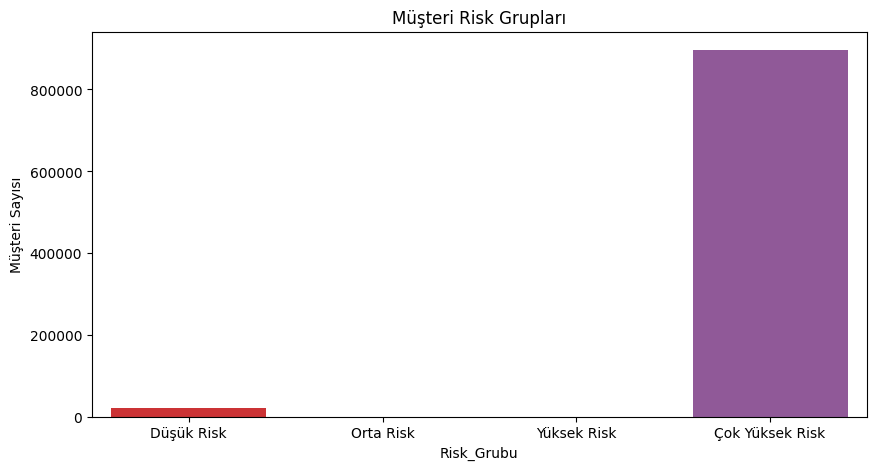

/tmp/ipykernel_527/2066933718.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tahsilat_1, x='Hesap Sınıfı', y='Risk_Skor', palette='Set2')


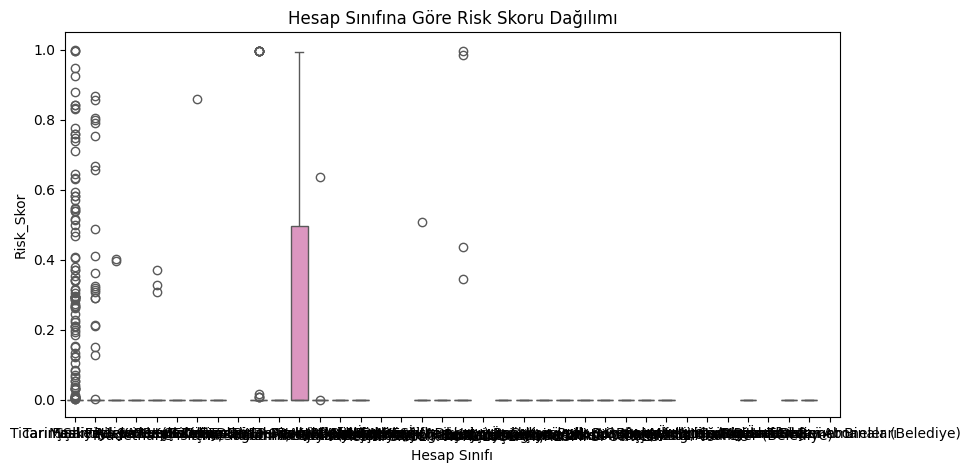

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(data=df_tahsilat_1, x='Risk_Grubu', palette='Set1', order=['Düşük Risk','Orta Risk','Yüksek Risk','Çok Yüksek Risk'])
plt.title("Müşteri Risk Grupları")
plt.ylabel("Müşteri Sayısı")
plt.show()


plt.figure(figsize=(10,5))
sns.boxplot(data=df_tahsilat_1, x='Hesap Sınıfı', y='Risk_Skor', palette='Set2')
plt.title("Hesap Sınıfına Göre Risk Skoru Dağılımı")
plt.show()

/tmp/ipykernel_527/920093676.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_527/920093676.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


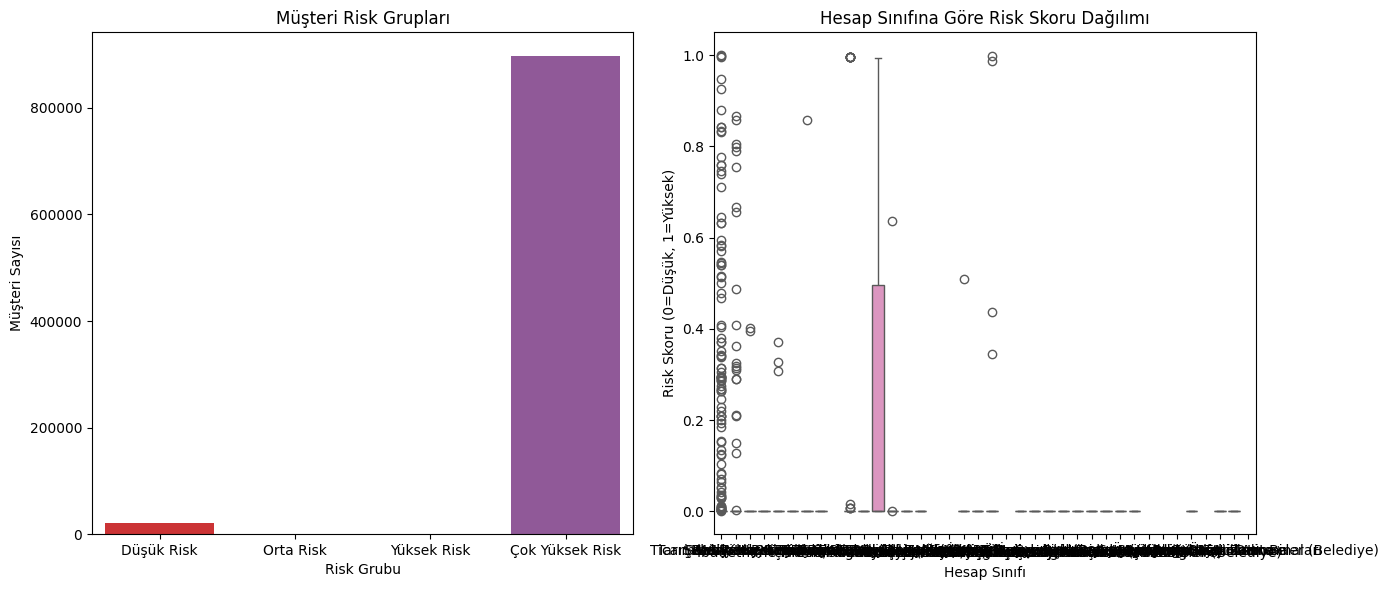

In [82]:

plt.figure(figsize=(14,6))


plt.subplot(1,2,1)
sns.countplot(
    data=df_tahsilat_1,
    x='Risk_Grubu',
    palette='Set1',
    order=['Düşük Risk','Orta Risk','Yüksek Risk','Çok Yüksek Risk']
)
plt.title("Müşteri Risk Grupları")
plt.ylabel("Müşteri Sayısı")
plt.xlabel("Risk Grubu")


plt.subplot(1,2,2)
sns.boxplot(
    data=df_tahsilat_1,
    x='Hesap Sınıfı',
    y='Risk_Skor',
    palette='Set2'
)
plt.title("Hesap Sınıfına Göre Risk Skoru Dağılımı")
plt.ylabel("Risk Skoru (0=Düşük, 1=Yüksek)")
plt.xlabel("Hesap Sınıfı")

plt.tight_layout()
plt.show()

Tahsilat süreçleri ve ödeme davranışları analizi
- Amaç: Ödeme davranışlarını etkileyen faktörleri keşfetmek ve riskli müşteri gruplarını tespit etmek.
- İlçe, Hesap Sınıfı ve Tüketim miktarının tahsilat performansına etkisi incelemek.


Hipotezler
1. Ticari aboneler ve yüksek tüketimli müşteriler daha yüksek risk oluşturuyor.
2. Bazı ilçelerde ödeme davranışları diğerlerine göre daha geç.
3. Zamanında ödeme oranı yüksek müşteriler, sadakat ve çapraz satış için daha uygun.

Bulgular
- Çoğu müşteri düşük veya orta risk grubunda.
- Yüksek risk ve çok yüksek risk grupları genellikle ticari hesap sınıfında ve yüksek tüketim grubunda.
- Bazı ilçelerde risk skoru daha yüksek gözlemleniyor.

İş Önerileri
- **Düşük Risk:** Standart tahsilat, çapraz satış fırsatları.
- **Orta Risk:** Hatırlatmalar, erken ödeme teşvikleri.
- **Yüksek / Çok Yüksek Risk:** Ödeme planı, teminat, birebir iletişim, öncelikli tahsilat.
- İlçe ve Hesap Sınıfı bazlı risk önceliklendirmesi yapılabilir.

